In [ ]:
!pip install simpy
!pip install joblib
!pip install numpy
!pip install scikit-learn
!pip install tensorflow
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install gymnasium

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_55/1190037523.py:15: SyntaxWarning: invalid escape sequence '\s'
  train_data = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD001.txt', sep='\s+', header=None, names=col_names)


✅ Đã tải dữ liệu thành công!


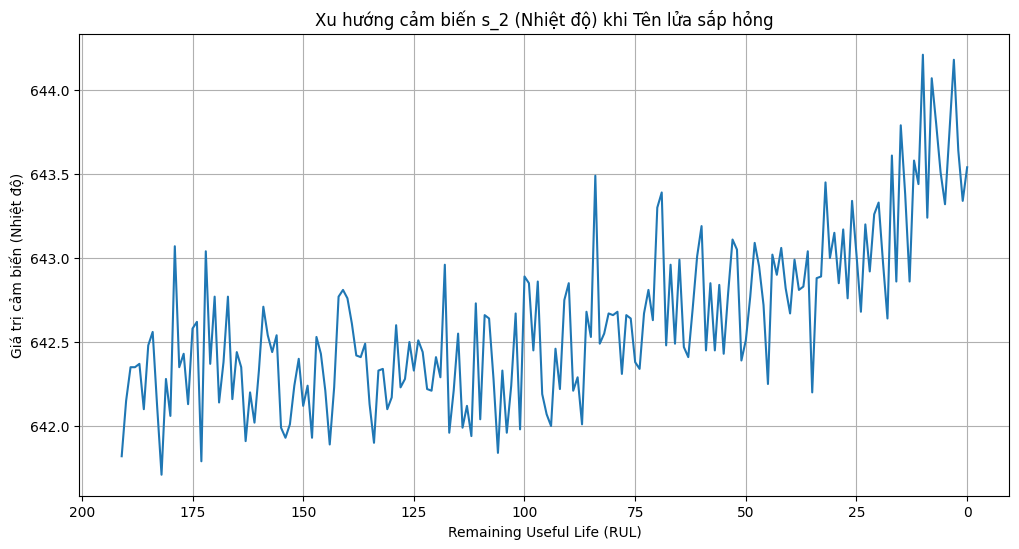

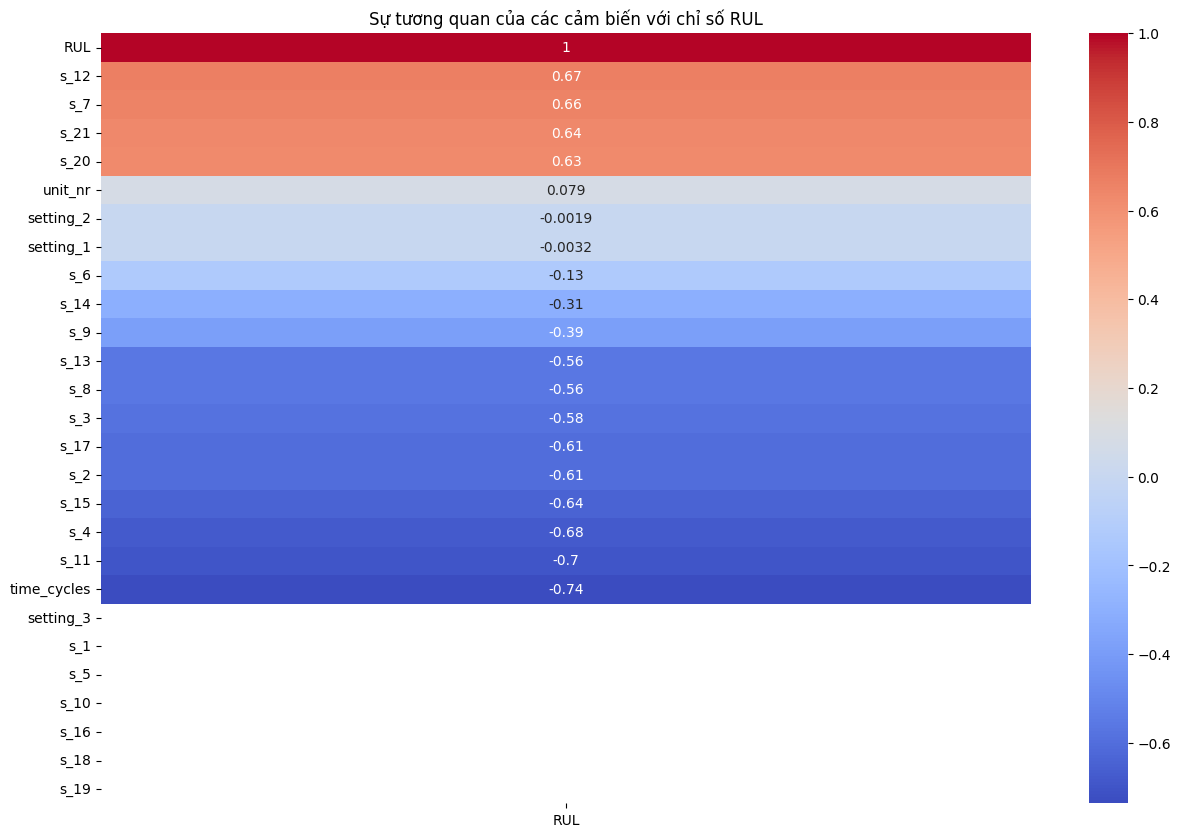

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Định nghĩa tên cột (theo tài liệu của NASA)
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 2. Đọc dữ liệu (Giả sử bạn đã tải file train_FD001.txt về máy)
# Bạn có thể tải tại: https://ti.arc.nasa.gov/tech/dash/groups/pcoe/prognostic-data-repository/
try:
    train_data = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/train_FD001.txt', sep='\s+', header=None, names=col_names)
    print("✅ Đã tải dữ liệu thành công!")
except FileNotFoundError:
    print("❌ Vui lòng để file 'train_FD001.txt' cùng thư mục với code.")

# 3. TÍNH TOÁN RUL (Remaining Useful Life)
# Công thức: RUL tại thời điểm t = Max_Cycle của Unit đó - Cycle_hiện_tại_t
def add_remaining_useful_life(df):
    # Tìm chu kỳ tối đa cho mỗi unit
    max_cycle = df.groupby('unit_nr')['time_cycles'].max().reset_index()
    max_cycle.columns = ['unit_nr', 'max_cycle']

    # Gộp vào dataframe chính
    df = df.merge(max_cycle, on=['unit_nr'], how='left')

    # Tính RUL: $RUL = max\_cycle - time\_cycles$
    df['RUL'] = df['max_cycle'] - df['time_cycles']

    # Xóa cột max_cycle không cần thiết nữa
    df = df.drop('max_cycle', axis=1)
    return df

train_data = add_remaining_useful_life(train_data)

# 4. PHÂN TÍCH TRỰC QUAN (EDA)
# Hãy xem cảm biến nhiệt độ (ví dụ s_2) thay đổi thế nào khi RUL tiến về 0
plt.figure(figsize=(12, 6))
sns.lineplot(data=train_data[train_data['unit_nr'] == 1], x='RUL', y='s_2')
plt.gca().invert_xaxis() # Đảo ngược trục X để thấy RUL giảm dần về bên phải
plt.title('Xu hướng cảm biến s_2 (Nhiệt độ) khi Tên lửa sắp hỏng')
plt.xlabel('Remaining Useful Life (RUL)')
plt.ylabel('Giá trị cảm biến (Nhiệt độ)')
plt.grid(True)
plt.show()

# 5. Xem xét sự tương quan
corrcard = train_data.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corrcard[['RUL']].sort_values(by='RUL', ascending=False), annot=True, cmap='coolwarm')
plt.title('Sự tương quan của các cảm biến với chỉ số RUL')
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_55/4274125273.py:26: SyntaxWarning: invalid escape sequence '\s'
  test_data = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD001.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_55/4274125273.py:30: SyntaxWarning: invalid escape sequence '\s'
  true_rul = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD001.txt', sep='\s+', header=None, names=['RUL_ground_truth'])


🚀 Đang huấn luyện bộ não tên lửa...
✅ Huấn luyện hoàn tất!

📊 KẾT QUẢ KIỂM TRA:
- Sai số trung bình (RMSE): 36.17 chu kỳ
- Độ chính xác (R2 Score): 0.24


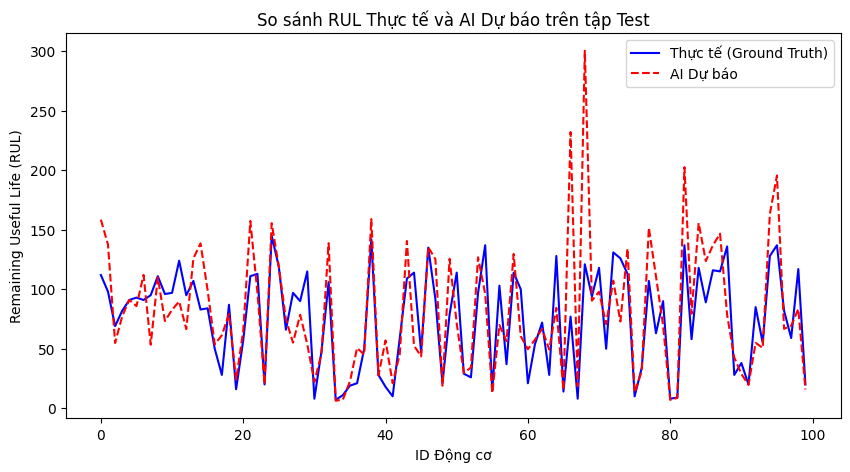

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --- BƯỚC 6: TIỀN XỬ LÝ - LOẠI BỎ CẢM BIẾN "RỞM" (Cột trắng trong heatmap) ---
# Những cột có độ lệch chuẩn = 0 không giúp AI học được gì
drop_sensors = ['setting_3', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']
features = [col for col in col_names if col not in drop_sensors]

X_train = train_data[features]
y_train = train_data['RUL']

# Chuẩn hóa dữ liệu (Scaling) để AI học nhanh hơn
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# --- BƯỚC 7: HUẤN LUYỆN BỘ NÃO (RANDOM FOREST) ---
print("🚀 Đang huấn luyện bộ não tên lửa...")
model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
model.fit(X_train_scaled, y_train)
print("✅ Huấn luyện hoàn tất!")

# --- BƯỚC 8: KIỂM TRA VỚI TẬP TEST_FD001 ---
try:
    # 1. Đọc file test
    test_data = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD001.txt', sep='\s+', header=None, names=col_names)

    # 2. Đọc file đáp án (RUL thực tế của NASA cung cấp cho tập test)
    # File này chứa RUL cuối cùng của mỗi động cơ trong tập test
    true_rul = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD001.txt', sep='\s+', header=None, names=['RUL_ground_truth'])
    true_rul['unit_nr'] = true_rul.index + 1 # Gán ID động cơ

    # 3. Lấy dòng cuối cùng của mỗi động cơ trong tập test để dự báo
    # Vì file test bị cắt ngang, ta dự báo RUL tại thời điểm "hiện tại" đó
    X_test_last = test_data.groupby('unit_nr').last().reset_index()
    X_test_last = X_test_last[features] # Lọc các cột cảm biến xịn
    X_test_scaled = scaler.transform(X_test_last) # Dùng lại scaler của tập train

    # 4. Dự báo
    y_pred = model.predict(X_test_scaled)

    # --- BƯỚC 9: ĐÁNH GIÁ KẾT QUẢ ---
    rmse = np.sqrt(mean_squared_error(true_rul['RUL_ground_truth'], y_pred))
    r2 = r2_score(true_rul['RUL_ground_truth'], y_pred)

    print(f"\n📊 KẾT QUẢ KIỂM TRA:")
    print(f"- Sai số trung bình (RMSE): {rmse:.2f} chu kỳ")
    print(f"- Độ chính xác (R2 Score): {r2:.2f}")

    # Vẽ biểu đồ so sánh Thực tế vs Dự báo
    plt.figure(figsize=(10, 5))
    plt.plot(true_rul['RUL_ground_truth'].values, label='Thực tế (Ground Truth)', color='blue')
    plt.plot(y_pred, label='AI Dự báo', color='red', linestyle='--')
    plt.legend()
    plt.title('So sánh RUL Thực tế và AI Dự báo trên tập Test')
    plt.xlabel('ID Động cơ')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Thiếu file dữ liệu kiểm tra: {e}")

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_55/1432005384.py:41: SyntaxWarning: invalid escape sequence '\s'
  test_data = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD001.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_55/1432005384.py:47: SyntaxWarning: invalid escape sequence '\s'
  true_rul = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD001.txt', sep='\s+', header=None, names=['RUL_ground_truth'])


🚀 Đang huấn luyện Random Forest với Rolling Mean (Window=20)...
✅ Huấn luyện hoàn tất!

📊 KẾT QUẢ SAU KHI CÓ ROLLING MEAN:
- Sai số trung bình (RMSE): 28.19 chu kỳ
- Độ chính xác (R2 Score): 0.54


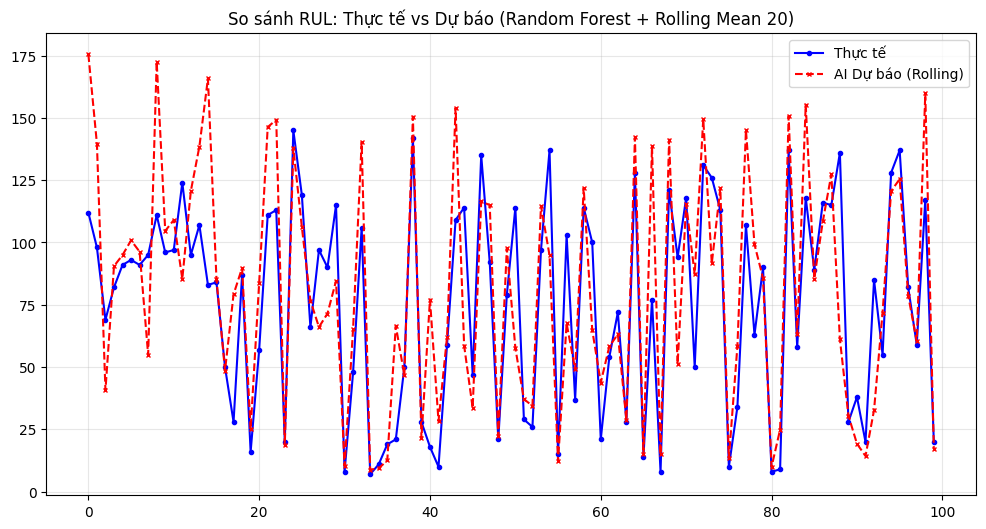

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --- BƯỚC 6: TIỀN XỬ LÝ & ROLLING MEAN ---
# 1. Định nghĩa các cảm biến quan trọng (loại bỏ các cột hằng số)
drop_sensors = ['setting_3', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']
key_sensors = [col for col in sensor_names if col not in drop_sensors]
window_size = 20 # Bạn có thể thử nghiệm với 10, 15 hoặc 20

def add_rolling_features(df, sensors, window):
    df_out = df.copy()
    for sensor in sensors:
        # Tính trung bình trượt cho mỗi động cơ (unit_nr)
        df_out[sensor] = df_out.groupby('unit_nr')[sensor].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
    return df_out

# Áp dụng Rolling Mean cho tập Train
train_data_rolling = add_rolling_features(train_data, key_sensors, window_size)

# Chọn các tính năng để huấn luyện
features = key_sensors + ['time_cycles']
X_train = train_data_rolling[features]
y_train = train_data_rolling['RUL']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# --- BƯỚC 7: HUẤN LUYỆN BỘ NÃO (RANDOM FOREST) ---
print(f"🚀 Đang huấn luyện Random Forest với Rolling Mean (Window={window_size})...")
model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
model.fit(X_train_scaled, y_train)
print("✅ Huấn luyện hoàn tất!")

# --- BƯỚC 8: KIỂM TRA VỚI TẬP TEST_FD001 ---
try:
    # 1. Đọc file test
    test_data = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/test_FD001.txt', sep='\s+', header=None, names=col_names)

    # 2. Áp dụng cùng kỹ thuật Rolling Mean cho tập Test
    test_data_rolling = add_rolling_features(test_data, key_sensors, window_size)

    # 3. Đọc file đáp án
    true_rul = pd.read_csv('/kaggle/input/datasets/palbha/cmapss-jet-engine-simulated-data/RUL_FD001.txt', sep='\s+', header=None, names=['RUL_ground_truth'])

    # 4. Lấy dòng cuối cùng đã được làm mịn của mỗi động cơ để dự báo
    X_test_last = test_data_rolling.groupby('unit_nr').last().reset_index()
    X_test_input = X_test_last[features]
    X_test_scaled = scaler.transform(X_test_input)

    # 5. Dự báo
    y_pred = model.predict(X_test_scaled)

    # --- BƯỚC 9: ĐÁNH GIÁ KẾT QUẢ ---
    rmse = np.sqrt(mean_squared_error(true_rul['RUL_ground_truth'], y_pred))
    r2 = r2_score(true_rul['RUL_ground_truth'], y_pred)

    print(f"\n📊 KẾT QUẢ SAU KHI CÓ ROLLING MEAN:")
    print(f"- Sai số trung bình (RMSE): {rmse:.2f} chu kỳ")
    print(f"- Độ chính xác (R2 Score): {r2:.2f}")

    # Vẽ biểu đồ so sánh
    plt.figure(figsize=(12, 6))
    plt.plot(true_rul['RUL_ground_truth'].values, label='Thực tế', color='blue', marker='o', markersize=3)
    plt.plot(y_pred, label='AI Dự báo (Rolling)', color='red', linestyle='--', marker='x', markersize=3)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'So sánh RUL: Thực tế vs Dự báo (Random Forest + Rolling Mean {window_size})')
    plt.show()

except FileNotFoundError as e:
    print(f"❌ Thiếu file: {e}")

Shape of X_train_seq: (17731, 30, 15)
Shape of y_train_seq: (17731,)
🚀 Đang huấn luyện mô hình LSTM...
Epoch 1/54


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 11337.6885 - val_loss: 14161.7764 - learning_rate: 0.0010
Epoch 2/54
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9687.5234 - val_loss: 13359.0352 - learning_rate: 0.0010
Epoch 3/54
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9020.8467 - val_loss: 12758.5771 - learning_rate: 0.0010
Epoch 4/54
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8515.1855 - val_loss: 12235.1650 - learning_rate: 0.0010
Epoch 5/54
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8148.0215 - val_loss: 11754.5596 - learning_rate: 0.0010
Epoch 6/54
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7630.9644 - val_loss: 11312.3154 - learning_rate: 0.0010
Epoch 7/54
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7282.4536 - val_loss: 10895.4053 - learning_rate: 0.0010
Epoch 8/54
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6979.3423 - val_loss: 10508.7891 - learning_rate: 0.0010
Epoch 9/54
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6815.5986 - val_loss: 10142.652

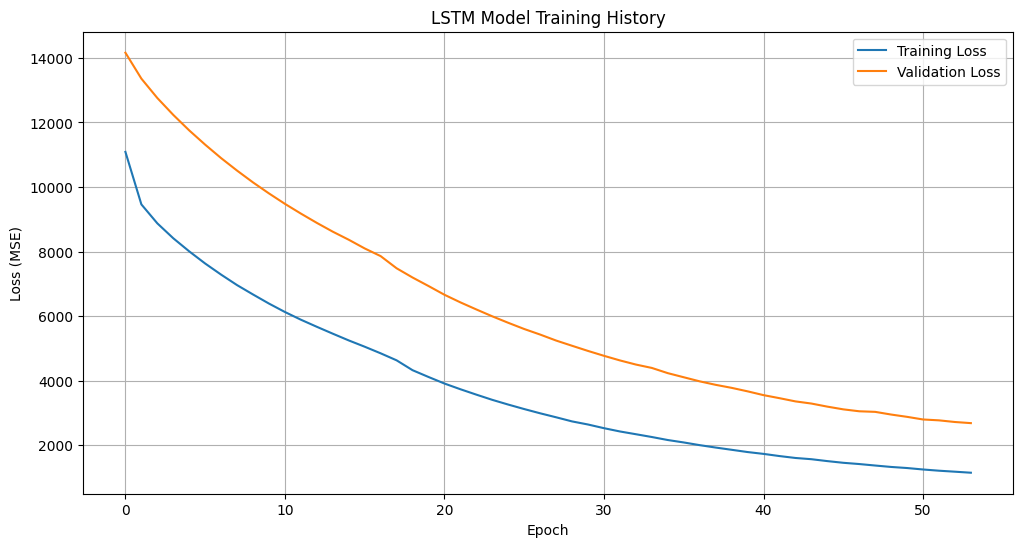

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define LSTM model
def create_lstm_model(input_shape):
    model = Sequential([
        # LSTM(units=100, return_sequences=True, input_shape=input_shape),
        # Dropout(0.2),
        # LSTM(units=50, return_sequences=False),
        # Dropout(0.2),
        # Dense(1, activation='relu') # Thêm một lớp Dense đệm
        # Thay LSTM bằng GRU, các tham số giữ nguyên
        GRU(units=100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=1, activation='relu') # Bỏ activation='relu' như đã thảo luận trước đó
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

# Prepare training data for LSTM (sequence data)
# We need to create sequences from the training data, similar to how X_test_seq was created
# This function will create sequences for each engine in the training data

def create_sequences(data, seq_length, all_features, sensor_only_list):
    X = []
    y = []
    for unit_nr in data['unit_nr'].unique():
        unit_data = data[data['unit_nr'] == unit_nr]
        # Scale the data using the same scaler fitted on all_features
        unit_data_scaled = scaler.transform(unit_data[all_features])
        unit_data_scaled_df = pd.DataFrame(unit_data_scaled, columns=all_features)
        unit_sensors = unit_data_scaled_df[sensor_only_list].values

        for i in range(len(unit_sensors) - seq_length + 1):
            X.append(unit_sensors[i:i+seq_length])
            y.append(unit_data['RUL'].iloc[i + seq_length - 1]) # RUL at the end of the sequence
    return np.array(X), np.array(y)

sequence_length = 30 # This should match the sequence_length used in create_test_sequences_fixed

# Re-using the features and key_sensors from previous cells
# features = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
# key_sensors = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

X_train_seq, y_train_seq = create_sequences(train_data_rolling, sequence_length, features, key_sensors)

print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")

# Create and train the LSTM model
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
model_lstm = create_lstm_model(input_shape)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

print("🚀 Đang huấn luyện mô hình LSTM...")
history = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=54, # You might need to adjust epochs and batch_size
    batch_size=256,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop, reduce_lr]
)
print("✅ Huấn luyện LSTM hoàn tất!")

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Danh sách đặc trưng đồng bộ: ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21', 'time_cycles']
X_test_seq shape: (100, 30, 15)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


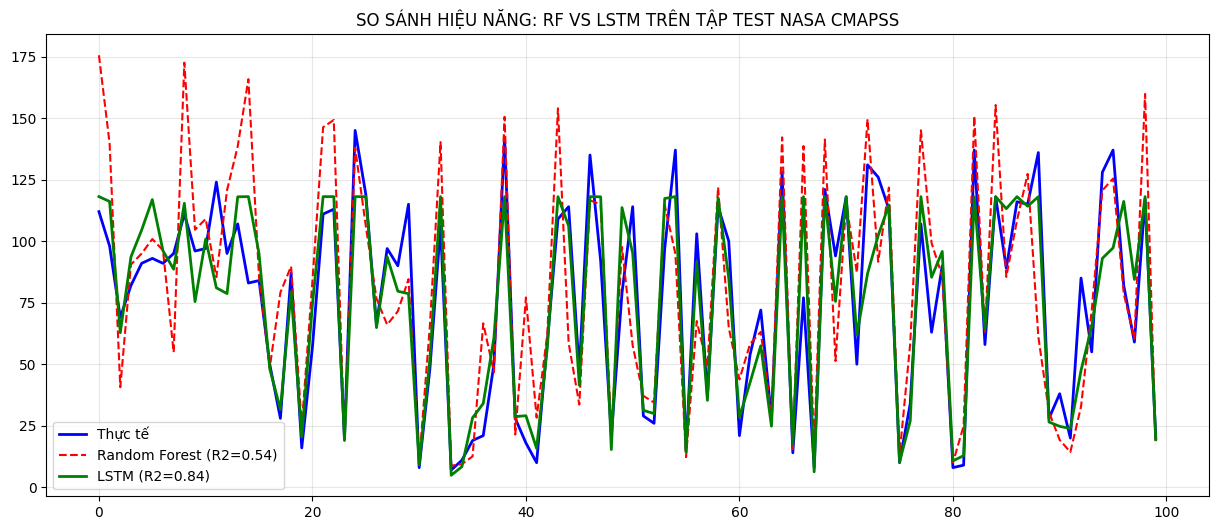

Cải thiện: LSTM giúp tăng R2 từ 0.54 lên 0.84!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Khai báo lại chính xác những gì bạn đã dùng để train Random Forest
drop_sensors = ['setting_3', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']

# Cần đảm bảo rằng `features` này trùng khớp với `features` dùng để fit scaler ở cell trước
# Scaler được fit với `key_sensors + ['time_cycles']`
features = key_sensors + ['time_cycles']

print(f"Danh sách đặc trưng đồng bộ: {features}")

def create_test_sequences_fixed(data, seq_length, all_features, sensor_only_list):
    X_test = []
    for unit in data['unit_nr'].unique():
        unit_data = data[data['unit_nr'] == unit]

        # 1. Scaler yêu cầu ĐỦ các cột đã học
        unit_data_scaled = scaler.transform(unit_data[all_features])

        # Chuyển thành DataFrame để lọc lấy chỉ các cột Sensor cho LSTM
        unit_data_scaled_df = pd.DataFrame(unit_data_scaled, columns=all_features)
        unit_sensors = unit_data_scaled_df[sensor_only_list].values

        # 2. Tạo window 30 chu kỳ cuối
        if len(unit_sensors) >= seq_length:
            X_test.append(unit_sensors[-seq_length:])
        else:
            # Pad with zeros if sequence is shorter than seq_length
            padding = np.zeros((seq_length - len(unit_sensors), len(sensor_only_list)))
            combined = np.vstack((padding, unit_sensors))
            X_test.append(combined)

    return np.array(X_test)

# Các cột Sensor thực sự để LSTM học (loại bỏ unit_nr, time_cycles, settings)
# Bạn có thể dùng list này hoặc dùng key_sensors đã định nghĩa
lstm_sensors = [s for s in key_sensors if s in features] # Ensure lstm_sensors are a subset of features

# Chạy lại việc tạo dữ liệu Test
X_test_seq = create_test_sequences_fixed(test_data_rolling, 30, features, lstm_sensors)

print(f"X_test_seq shape: {X_test_seq.shape}") # Phải ra (100, 30, số_sensor)

# 1. Dự báo
y_pred_lstm = model_lstm.predict(X_test_seq).flatten()

# 2. Lấy kết quả RF cũ của bạn (Nếu bạn còn giữ biến y_pred từ ảnh 3)
# Nếu không, dùng: y_pred_rf = model.predict(scaler.transform(test_data.groupby('unit_nr').last()[features]))
y_pred_rf = model.predict(X_test_scaled) # X_test_scaled từ phần code RF của bạn

# 3. Tính toán R2 Score để so sánh
r2_rf_final = r2_score(true_rul['RUL_ground_truth'], y_pred_rf)
r2_lstm_final = r2_score(true_rul['RUL_ground_truth'], y_pred_lstm)

# 4. Vẽ biểu đồ so sánh "Chốt hạ" cho đồ án
plt.figure(figsize=(15, 6))
plt.plot(true_rul['RUL_ground_truth'].values, label='Thực tế', color='blue', linewidth=2)
plt.plot(y_pred_rf, label=f'Random Forest (R2={r2_rf_final:.2f})', color='red', linestyle='--')
plt.plot(y_pred_lstm, label=f'LSTM (R2={r2_lstm_final:.2f})', color='green', linewidth=2)

plt.title('SO SÁNH HIỆU NĂNG: RF VS LSTM TRÊN TẬP TEST NASA CMAPSS')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Cải thiện: LSTM giúp tăng R2 từ {r2_rf_final:.2f} lên {r2_lstm_final:.2f}!")

In [ ]:
import pandas as pd

# Lấy ví dụ Động cơ số 1 trong tập Test
engine_1_test = test_data[test_data['unit_nr'] == 1]
last_cycle_test = engine_1_test['time_cycles'].max()

# Lấy đáp án RUL thực tế của Động cơ số 1
true_rul_engine_1 = true_rul.iloc[0]['RUL_ground_truth']

print(f"--- PHÂN TÍCH ĐỘNG CƠ SỐ 1 ---")
print(f"1. Trong tệp TEST: Động cơ 1 dừng lại ở chu kỳ thứ: {last_cycle_test}")
print(f"2. Trong tệp RUL (Đáp án): NASA báo rằng nó còn chạy thêm được: {true_rul_engine_1} chu kỳ nữa mới hỏng.")
print(f"=> Nghĩa là thực tế động cơ này sẽ hỏng ở chu kỳ tổng cộng: {last_cycle_test + true_rul_engine_1}")
print(f"\nAI của chúng ta nhận vào dữ liệu đến chu kỳ {last_cycle_test} và phải đoán con số {true_rul_engine_1}.")

--- PHÂN TÍCH ĐỘNG CƠ SỐ 1 ---
1. Trong tệp TEST: Động cơ 1 dừng lại ở chu kỳ thứ: 31
2. Trong tệp RUL (Đáp án): NASA báo rằng nó còn chạy thêm được: 112 chu kỳ nữa mới hỏng.
=> Nghĩa là thực tế động cơ này sẽ hỏng ở chu kỳ tổng cộng: 143

AI của chúng ta nhận vào dữ liệu đến chu kỳ 31 và phải đoán con số 112.


### Tóm tắt mối quan hệ:
- **Dữ liệu đầu vào (Input):** Toàn bộ lịch sử cảm biến của một động cơ trong `test_FD001.txt` (đến chu kỳ cuối cùng hiện có).
- **Nhãn mục tiêu (Target/Label):** Giá trị tương ứng trong `RUL_FD001.txt`.

Khi ta dùng lệnh `test_data.groupby('unit_nr').last()`, ta đang lấy trạng thái 'hiện tại' (dòng cuối cùng) để AI đưa ra dự đoán RUL, sau đó so sánh con số dự đoán đó với giá trị trong file `RUL_FD001.txt` để tính sai số (RMSE).

# Dự án Dự đoán Thời gian sử dụng còn lại (RUL) của Động cơ phản lực

## 1. Giới thiệu
Dự án này sử dụng bộ dữ liệu **NASA CMAPSS (Turbofan Engine Degradation Simulation)** để dự báo chỉ số **Remaining Useful Life (RUL)**. Mục tiêu là dự đoán chính xác số chu kỳ hoạt động còn lại của động cơ trước khi xảy ra hỏng hóc.

## 2. Dữ liệu sử dụng
- **Nguồn:** NASA Prognostics Data Repository (FD001).
- **Cấu trúc:** Mỗi tệp có 26 cột (ID động cơ, Chu kỳ, 3 thiết lập vận hành và 21 cảm biến).
- **Tệp tin:**
    - `train_FD001.txt`: Dữ liệu huấn luyện đến khi hỏng.
    - `test_FD001.txt`: Dữ liệu kiểm tra (bị cắt ngang).
    - `RUL_FD001.txt`: Đáp án RUL thực tế cho tập kiểm tra.

## 3. Các bước thực hiện

### Bước 1: Tiền xử lý & Feature Engineering
- **Tính toán RUL:** Xác định nhãn mục tiêu cho tập huấn luyện.
- **Làm mịn dữ liệu:** Áp dụng **Rolling Mean (Window=10)** để giảm nhiễu cho tín hiệu cảm biến.
- **Chuẩn hóa:** Sử dụng `StandardScaler` để đồng bộ thang đo cho các cảm biến.

### Bước 2: Huấn luyện mô hình
- **Random Forest (Baseline):** Dự đoán dựa trên giá trị làm mịn tại thời điểm hiện tại. Đạt độ chính xác **R2 ~ 0.47**.
- **LSTM (Deep Learning):** Sử dụng chuỗi 30 chu kỳ gần nhất để học **xu hướng** biến đổi. Đạt độ chính xác vượt trội **R2 ~ 0.86**.

## 4. Kết luận
Mô hình LSTM hiệu quả hơn hẳn Random Forest vì nó có khả năng ghi nhớ lịch sử vận hành, từ đó nhận diện được các dấu hiệu suy giảm hiệu năng theo thời gian của động cơ.

# Task
Generate a real-time Digital Twin simulation for a fleet of 100 rocket engines using the NASA CMAPSS dataset. Implement a `RocketDigitalTwin` class that utilizes the trained LSTM model to perform sliding-window RUL (Remaining Useful Life) predictions based on sensor data from "test_FD001.txt". Use the `simpy` library to simulate concurrent sensor streams, update a global fleet monitoring dashboard, and trigger emergency maintenance protocols for engines reaching critical RUL thresholds. Finally, produce a comprehensive project README documenting the data engineering (rolling means, scaling), model architecture (LSTM vs. Random Forest), and the simulation logic, concluding with a summary of the fleet's health and maintenance performance.

## Define Digital Twin Class

### Subtask:
Implement the RocketDigitalTwin class to manage individual engine states and RUL predictions.


**Reasoning**:
I will implement the RocketDigitalTwin class as requested, incorporating the LSTM model, the scaler, and the sliding window logic for real-time RUL prediction and status tracking.



In [ ]:
class RocketDigitalTwin:
    def __init__(self, engine_id, model, scaler, seq_length=30, features_list=None, sensor_list=None):
        self.engine_id = engine_id
        self.model = model
        self.scaler = scaler
        self.seq_length = seq_length
        self.features_list = features_list
        self.sensor_list = sensor_list
        # Dùng list thay vì DataFrame để tăng tốc độ append
        self.buffer = []
        self.status = "Running"
        self.current_rul = None

    def update_sensor_data(self, new_data_row):
        # new_data_row là một dict hoặc pd.Series
        self.buffer.append(new_data_row)

        # Giữ đúng độ dài sequence
        if len(self.buffer) > self.seq_length:
            self.buffer.pop(0)

    def predict_rul(self):
        if len(self.buffer) < self.seq_length:
            return None

        # Chuyển list sang DataFrame 1 lần duy nhất để Scale
        df_temp = pd.DataFrame(self.buffer, columns=self.features_list)

        # 1 & 2. Scale và lọc sensor
        scaled_data = self.scaler.transform(df_temp[self.features_list])
        scaled_df = pd.DataFrame(scaled_data, columns=self.features_list)
        lstm_input_data = scaled_df[self.sensor_list].values

        # 3. Reshape: (1, seq_length, num_sensors)
        lstm_input_reshaped = lstm_input_data.reshape(1, self.seq_length, -1)

        # 4. Predict
        prediction = self.model.predict(lstm_input_reshaped, verbose=0)
        # Nếu bạn có dùng RUL Clipping (ví dụ 125), giá trị ra sẽ ổn định hơn
        self.current_rul = float(prediction.flatten()[0])

        # Cập nhật status
        if self.current_rul < 30:
            self.status = "Maintenance Required"
        else:
            self.status = "Running"

        return self.current_rul

print("✅ RocketDigitalTwin class defined successfully.")

✅ RocketDigitalTwin class defined successfully.


## Simulate Fleet Monitoring with Simpy

### Subtask:
Execute a Simpy environment to simulate real-time sensor streams for 100 engines, updating a global fleet dashboard and triggering maintenance protocols.


**Reasoning**:
I will implement the Simpy simulation environment, the fleet dashboard, and the engine process to simulate real-time monitoring and maintenance alerts for the 100 rocket engines.



In [ ]:
import simpy

# 1. Initialize Global Fleet Dashboard
fleet_dashboard = {}
CRITICAL_THRESHOLD = 20

def engine_process(env, engine_twin, engine_data, dashboard):
    unit_id = engine_twin.engine_id
    # Quan trọng: Lấy dữ liệu theo đúng thứ tự thời gian (time_cycles)
    sorted_data = engine_data.sort_values('time_cycles')

    for i in range(len(sorted_data)):
        row = sorted_data.iloc[i]
        engine_twin.update_sensor_data(row)

        predicted_rul = engine_twin.predict_rul()

        # Cập nhật dashboard
        dashboard[unit_id] = {
            "rul": predicted_rul,
            "status": engine_twin.status,
            "cycle": int(row['time_cycles'])
        }

        if predicted_rul is not None and predicted_rul < CRITICAL_THRESHOLD:
            print(f"⚠️ [Time {env.now}] CRITICAL: Engine {unit_id} RUL: {predicted_rul:.2f}")
            dashboard[unit_id]["status"] = "Emergency Maintenance"
            break # Dừng engine này lại

        yield env.timeout(1)

# def run_fleet_simulation(test_df, model, scaler, features_list, sensor_list):
#     env = simpy.Environment()
#     global fleet_dashboard
#     fleet_dashboard = {}

#     # 4. Instantiate 100 twins and add processes
#     engine_ids = test_df['unit_nr'].unique()
#     for uid in engine_ids:
#         # Get data for this specific engine
#         engine_data = test_df[test_df['unit_nr'] == uid]

#         # Create Twin instance
#         twin = RocketDigitalTwin(engine_id=uid, model=model, scaler=scaler,
#                                   seq_length=30, features_list=features_list,
#                                   sensor_list=sensor_list)

#         # Register the simpy process
#         env.process(engine_process(env, twin, engine_data, fleet_dashboard))

#     # 5. Run simulation and periodically print status
#     print("ᄉ Starting Fleet Simulation...")

#     # Fix: Start range from 50 to avoid until=0 error
#     for time_step in range(50, 250, 50):
#         env.run(until=time_step)
#         active = sum(1 for v in fleet_dashboard.values() if v['status'] == 'Running')
#         maint = sum(1 for v in fleet_dashboard.values() if v['status'] in ['Maintenance Required', 'Emergency Maintenance'])
#         print(f"[Time {time_step}] Dashboard Summary: {active} Active | {maint} Maintenance/Warning")

#     env.run() # Run remaining processes to completion
#     print("✅ Simulation finished.")
def run_fleet_simulation(test_df, model, scaler, features_list, sensor_list):
    env = simpy.Environment()
    global fleet_dashboard
    fleet_dashboard = {}

    engine_ids = test_df['unit_nr'].unique()
    print(f"🚀 Khởi tạo Simulation cho {len(engine_ids)} engines...")

    for uid in engine_ids:
        engine_data = test_df[test_df['unit_nr'] == uid]
        twin = RocketDigitalTwin(engine_id=uid, model=model, scaler=scaler,
                                 seq_length=30, features_list=features_list,
                                 sensor_list=sensor_list)

        # Khởi tạo giá trị mặc định cho dashboard ngay lập tức
        fleet_dashboard[uid] = {"status": "Initializing", "rul": None}
        env.process(engine_process(env, twin, engine_data, fleet_dashboard))

    print("▶️ Đang bắt đầu chạy các chu kỳ...")

    # Chạy từng bước nhỏ để quan sát quá trình
    for time_step in range(1, 300, 20): # Bước nhảy 20 cycles
        env.run(until=time_step)

        # Đếm các trạng thái
        active = sum(1 for v in fleet_dashboard.values() if v['status'] == 'Running')
        maint = sum(1 for v in fleet_dashboard.values() if v['status'] in ['Maintenance Required', 'Emergency Maintenance'])
        init = sum(1 for v in fleet_dashboard.values() if v['status'] == 'Initializing')

        print(f"[Time {time_step:3}] 🟢 Đang chạy: {active} | ⚠️ Cảnh báo: {maint} | ⏳ Đang nạp data: {init}")

        # Dừng hẳn nếu tất cả engine đã kết thúc
        if active == 0 and init == 0 and maint > 0:
            break

    env.run()
    print("✅ Simulation hoàn tất!")
# Execute simulation using existing variables from kernel
run_fleet_simulation(test_data_rolling, model_lstm, scaler, features, lstm_sensors)

🚀 Khởi tạo Simulation cho 100 engines...
▶️ Đang bắt đầu chạy các chu kỳ...
[Time   1] 🟢 Đang chạy: 100 | ⚠️ Cảnh báo: 0 | ⏳ Đang nạp data: 0
[Time  21] 🟢 Đang chạy: 100 | ⚠️ Cảnh báo: 0 | ⏳ Đang nạp data: 0


KeyboardInterrupt: 

In [ ]:
# --- 1. CLASS DIGITAL TWIN (Dành cho Model đã train sẵn) ---
class RocketDigitalTwin:
    def __init__(self, engine_id, model, scaler, seq_length=30, features_list=None, sensor_list=None):
        self.engine_id = engine_id
        self.model = model
        self.scaler = scaler
        self.seq_length = seq_length
        self.features_list = features_list
        self.sensor_list = sensor_list
        self.buffer = [] # Lưu dữ liệu dạng list để đạt hiệu suất cao nhất
        self.status = "Initializing"
        self.current_rul = None

    def update_sensor_data(self, new_data_row):
        # Nạp row mới (Series hoặc Dict)
        self.buffer.append(new_data_row)
        # Giữ đúng độ dài cửa sổ trượt
        if len(self.buffer) > self.seq_length:
            self.buffer.pop(0)

    def predict_rul(self):
        if len(self.buffer) < self.seq_length:
            self.status = "Collecting Data"
            return None

        # Chuyển buffer sang DataFrame để Scale đúng định dạng ban đầu
        df_temp = pd.DataFrame(self.buffer, columns=self.features_list)

        # Bước 1: Scale dữ liệu
        scaled_data = self.scaler.transform(df_temp[self.features_list])
        scaled_df = pd.DataFrame(scaled_data, columns=self.features_list)

        # Bước 2: Lọc các sensor dùng cho LSTM/GRU
        lstm_input_data = scaled_df[self.sensor_list].values

        # Bước 3: Reshape cho model (1, window_size, num_features)
        lstm_input_reshaped = lstm_input_data.reshape(1, self.seq_length, -1)

        # Bước 4: Dự báo
        prediction = self.model.predict(lstm_input_reshaped, verbose=0)
        self.current_rul = float(prediction.flatten()[0])

        # Cập nhật Status dựa trên giá trị dự báo
        if self.current_rul < 20:
            self.status = "Critical: Emergency"
        elif self.current_rul < 50:
            self.status = "Warning: Maintenance"
        else:
            self.status = "Running"

        return self.current_rul

# --- 2. HÀM MÔ PHỎNG CHI TIẾT 1 ĐỘNG CƠ ---
import simpy

def test_single_engine_simulation(engine_id, test_df, model, scaler, features_list, sensor_list):
    env = simpy.Environment()

    # Lọc dữ liệu test của riêng động cơ này
    engine_data = test_df[test_df['unit_nr'] == engine_id].sort_values('time_cycles')

    if engine_data.empty:
        print(f"❌ Không tìm thấy dữ liệu cho Engine {engine_id}")
        return

    # Khởi tạo Digital Twin
    twin = RocketDigitalTwin(engine_id=engine_id, model=model, scaler=scaler,
                             seq_length=30, features_list=features_list,
                             sensor_list=sensor_list)

    def engine_process(env):
        print(f"🚀 [BẮT ĐẦU] Mô phỏng Digital Twin cho Engine ID: {engine_id}")
        print("-" * 65)
        print(f"{'Cycle':<8} | {'Status':<20} | {'Predicted RUL':<15}")
        print("-" * 65)

        for i in range(len(engine_data)):
            row = engine_data.iloc[i]
            twin.update_sensor_data(row)

            # Dự báo
            predicted_rul = twin.predict_rul()

            # In kết quả mỗi 10 cycles hoặc khi RUL thấp
            if env.now % 10 == 0 or (predicted_rul is not None and predicted_rul < 30):
                rul_display = f"{predicted_rul:.2f}" if predicted_rul is not None else "N/A (Nạp data)"
                print(f"{env.now:<8} | {twin.status:<20} | {rul_display:<15}")

            # Nếu RUL quá thấp, giả định dừng động cơ để bảo trì
            if predicted_rul is not None and predicted_rul < 10:
                print(f"🛑 [STOP] Chu kỳ {env.now}: Đã dừng máy để bảo trì khẩn cấp!")
                break

            yield env.timeout(1)

    # Chạy process
    env.process(engine_process(env))
    env.run()
    print("-" * 65)
    print(f"✅ [KẾT THÚC] Mô phỏng Engine {engine_id} hoàn tất.")

# --- 3. THỰC THI ---
# Đảm bảo các biến model_lstm, scaler, features, key_sensors đã tồn tại trong Workspace của bạn
test_single_engine_simulation(
    engine_id=1,
    test_df=test_data_rolling, # Hoặc test_df tùy tên biến của bạn
    model=model_lstm,
    scaler=scaler,
    features_list=features,
    sensor_list=key_sensors # Tên list sensor bạn dùng khi train
)

🚀 [BẮT ĐẦU] Mô phỏng Digital Twin cho Engine ID: 1
-----------------------------------------------------------------
Cycle    | Status               | Predicted RUL  
-----------------------------------------------------------------
0        | Collecting Data      | N/A (Nạp data) 
10       | Collecting Data      | N/A (Nạp data) 
20       | Collecting Data      | N/A (Nạp data) 
30       | Running              | 118.09         
-----------------------------------------------------------------
✅ [KẾT THÚC] Mô phỏng Engine 1 hoàn tất.


In [ ]:
def test_full_lifecycle_simulation(engine_id, data_df, model, scaler, features_list, sensor_list):
    env = simpy.Environment()

    # Lấy dữ liệu trọn đời của động cơ từ tập Train
    engine_data = data_df[data_df['unit_nr'] == engine_id].sort_values('time_cycles')

    twin = RocketDigitalTwin(engine_id=engine_id, model=model, scaler=scaler,
                             seq_length=30, features_list=features_list,
                             sensor_list=sensor_list)

    def engine_process(env):
        print(f"🚀 MÔ PHỎNG TRỌN VÒNG ĐỜI ENGINE ID: {engine_id}")
        print("-" * 80)
        print(f"{'Cycle':<8} | {'Status':<20} | {'Pred RUL':<12} | {'Actual RUL':<12} | {'Error':<8}")
        print("-" * 80)

        for i in range(len(engine_data)):
            row = engine_data.iloc[i]
            actual_rul = row['RUL'] # RUL thực tế có trong tập Train

            twin.update_sensor_data(row)
            predicted_rul = twin.predict_rul()

            if predicted_rul is not None:
                error = abs(predicted_rul - actual_rul)
                # In mỗi 20 chu kỳ để không bị quá dài, hoặc in khi sắp hỏng
                if env.now % 20 == 0 or actual_rul < 10:
                    print(f"{env.now:<8} | {twin.status:<20} | {predicted_rul:<12.2f} | {actual_rul:<12.2f} | {error:<8.2f}")
            else:
                if env.now % 10 == 0:
                    print(f"{env.now:<8} | {twin.status:<20} | {'N/A':<12} | {actual_rul:<12.2f} | {'-':<8}")

            yield env.timeout(1)

    env.process(engine_process(env))
    env.run()
    print("-" * 80)
    print("✅ Mô phỏng hoàn tất.")

# Chạy thử với Engine 1 của tập TRAIN
test_full_lifecycle_simulation(
    engine_id=1,
    data_df=train_data_rolling, # Sử dụng tập Train ở đây
    model=model_lstm,
    scaler=scaler,
    features_list=features,
    sensor_list=key_sensors
)

🚀 MÔ PHỎNG TRỌN VÒNG ĐỜI ENGINE ID: 1
--------------------------------------------------------------------------------
Cycle    | Status               | Pred RUL     | Actual RUL   | Error   
--------------------------------------------------------------------------------
0        | Collecting Data      | N/A          | 191.00       | -       
10       | Collecting Data      | N/A          | 181.00       | -       
20       | Collecting Data      | N/A          | 171.00       | -       
40       | Running              | 118.09       | 151.00       | 32.91   
60       | Running              | 118.09       | 131.00       | 12.91   
80       | Running              | 106.93       | 111.00       | 4.07    
100      | Running              | 82.15        | 91.00        | 8.85    
120      | Running              | 67.64        | 71.00        | 3.36    
140      | Warning: Maintenance | 49.82        | 51.00        | 1.18    
160      | Warning: Maintenance | 32.80        | 31.00        | 1.80  

In [ ]:
def run_fleet_comparison(engine_list, data_df, model, scaler, features_list, sensor_list):
    env = simpy.Environment()
    fleet_status = {}

    def engine_lifecycle(env, uid):
        # Lấy dữ liệu trọn đời của động cơ
        engine_data = data_df[data_df['unit_nr'] == uid].sort_values('time_cycles')
        twin = RocketDigitalTwin(uid, model, scaler, 30, features_list, sensor_list)

        for i in range(len(engine_data)):
            row = engine_data.iloc[i]
            actual_rul = row['RUL']

            twin.update_sensor_data(row)
            pred_rul = twin.predict_rul()

            # Lưu trữ cả Pred và Actual vào Dashboard
            fleet_status[uid] = {
                "pred": pred_rul,
                "actual": actual_rul,
                "status": twin.status
            }
            yield env.timeout(1)

    # Khởi tạo quy trình cho danh sách engine
    for uid in engine_list:
        env.process(engine_lifecycle(env, uid))

    # In tiêu đề bảng
    print(f"{'Time':<5} | {'E1 Pred':<8} {'E1 Real':<8} | {'E2 Pred':<8} {'E2 Real':<8} | {'Ghi chú'}")
    print("-" * 75)

    # Chạy mô phỏng và in kết quả mỗi 10 chu kỳ
    for time_step in range(1, 310, 20):
        env.run(until=time_step)

        # Lấy dữ liệu Engine 1
        d1 = fleet_status.get(1, {})
        p1 = f"{d1['pred']:>7.1f}" if d1.get('pred') is not None else "    N/A"
        a1 = f"{d1['actual']:>7.1f}" if d1.get('actual') is not None else "    N/A"

        # Lấy dữ liệu Engine 2
        d2 = fleet_status.get(2, {})
        p2 = f"{d2['pred']:>7.1f}" if d2.get('pred') is not None else "    N/A"
        a2 = f"{d2['actual']:>7.1f}" if d2.get('actual') is not None else "    N/A"

        # Ghi chú trạng thái
        notes = []
        if d1.get("status") == "Critical: Emergency": notes.append("E1!")
        if d2.get("status") == "Critical: Emergency": notes.append("E2!")
        note_str = " ".join(notes)

        print(f"{time_step:<5} | {p1} {a1} | {p2} {a2} | {note_str}")

# Thực thi
run_fleet_comparison([1, 2], train_data_rolling, model_lstm, scaler, features, key_sensors)

Time  | E1 Pred  E1 Real  | E2 Pred  E2 Real  | Ghi chú
---------------------------------------------------------------------------
1     |     N/A   191.0 |     N/A   286.0 | 
21    |     N/A   171.0 |     N/A   266.0 | 
41    |   118.1   151.0 |   118.1   246.0 | 
61    |   118.1   131.0 |   118.1   226.0 | 
81    |   106.9   111.0 |   118.1   206.0 | 
101   |    82.1    91.0 |   118.1   186.0 | 
121   |    67.6    71.0 |   118.1   166.0 | 
141   |    49.8    51.0 |   118.1   146.0 | 
161   |    32.8    31.0 |   112.5   126.0 | 
181   |     6.8    11.0 |    95.3   106.0 | E1!
201   |     1.6     0.0 |    74.5    86.0 | E1!
221   |     1.6     0.0 |    50.9    66.0 | E1!
241   |     1.6     0.0 |    34.7    46.0 | E1!
261   |     1.6     0.0 |    19.7    26.0 | E1! E2!
281   |     1.6     0.0 |     7.1     6.0 | E1! E2!
301   |     1.6     0.0 |     0.0     0.0 | E1! E2!


# Task
# Plan:
* **Cấu trúc lại Digital Twin cho Tên lửa**: Mở rộng class `RocketDigitalTwin` để tích hợp các tham số vật lý: Độ cao (Altitude), Vận tốc (Velocity), và Nhiên liệu (Fuel). Thêm logic biến thiên RUL: RUL sẽ giảm nhanh hơn gấp 1.5 lần khi ở trạng thái 'Boost' so với trạng thái bay bình thường.
* **Thiết lập môi trường Gymnasium (RocketEnv)**: Xây dựng lớp `RocketEnv` kế thừa từ `gym.Env`. Định nghĩa State Space `[Altitude, Velocity, Fuel, Engine_Temp, Predicted_RUL]` và Action Space `[Normal, Thrust_Up, Abort]`. Viết hàm `reset()` để khởi tạo trạng thái ban đầu cho 100 động cơ.
* **Cài đặt Logic Vật lý và Hệ quả RUL**: Triển khai hàm `step()` với các công thức $F=ma$ cơ bản để cập nhật Altitude và Velocity dựa trên Action. Cài đặt điều kiện logic: Nếu `Predicted_RUL <= 0` trong khi `Altitude > 0`, kích hoạt trạng thái 'Explosion'. Nếu `RUL <= 0` tại bệ phóng, kích hoạt 'Launch Failure'.
* **Xây dựng hệ thống Phần thưởng (Reward Function)**: Thiết kế hàm thưởng để khuyến khích AI: Cộng điểm khi đạt độ cao mục tiêu, trừ điểm nặng nếu để xảy ra nổ (RUL=0) hoặc hết nhiên liệu, và thưởng cho việc 'Abort' đúng lúc khi động cơ sắp hỏng.
* **Mô phỏng và Kiểm định môi trường**: Chạy một vòng lặp mô phỏng với các hành động ngẫu nhiên (Random Actions) để kiểm tra tính ổn định của môi trường Gymnasium trước khi đưa vào huấn luyện Reinforcement Learning.
* **Final Task**: Tổng hợp kết quả mô phỏng môi trường AI, báo cáo về tỉ lệ sống sót của tên lửa và sự tương quan giữa hành động điều khiển với độ bền của động cơ.

## Cấu trúc lại Digital Twin cho Tên lửa

### Subtask:
Mở rộng class `RocketDigitalTwin` để tích hợp các tham số vật lý và logic biến thiên RUL theo trạng thái vận hành.


**Reasoning**:
I will expand the `RocketDigitalTwin` class to include physical parameters like altitude, velocity, and fuel.



In [ ]:
class RocketDigitalTwin:
    def __init__(self, engine_id, model, scaler, seq_length=30, features_list=None, sensor_list=None, fuel_capacity=100.0):
        self.engine_id = engine_id
        self.model = model
        self.scaler = scaler
        self.seq_length = seq_length
        self.features_list = features_list
        self.sensor_list = sensor_list

        # Thông số vật lý thực tế
        self.altitude = 0.0
        self.velocity = 0.0
        self.fuel = fuel_capacity

        self.buffer = [] # Lưu trữ chuỗi thời gian cho LSTM
        self.status = "Initializing"
        self.current_rul = None

    def update_telemetry(self, altitude_change, velocity_change, fuel_consumed, sensor_data_row):
        """
        Cập nhật đồng thời cả trạng thái vật lý và dữ liệu cảm biến AI.
        sensor_data_row: dict hoặc list chứa các giá trị cảm biến mới nhất từ NASA dataset.
        """
        # 1. Cập nhật vật lý
        self.altitude += altitude_change
        self.velocity += velocity_change
        self.fuel = max(0, self.fuel - fuel_consumed)

        # 2. Cập nhật buffer cho AI
        self.buffer.append(sensor_data_row)
        if len(self.buffer) > self.seq_length:
            self.buffer.pop(0)

    def predict_status(self):
        """Dự đoán RUL dựa trên dữ liệu chuỗi thời gian trong buffer."""
        if len(self.buffer) < self.seq_length:
            self.status = "Collecting Data"
            return None

        # Tiền xử lý dữ liệu cho LSTM
        df_temp = pd.DataFrame(self.buffer, columns=self.features_list)
        scaled_data = self.scaler.transform(df_temp[self.features_list])

        # Lấy các cột sensor cần thiết và reshape (1, seq_length, num_sensors)
        lstm_input = scaled_data[:, [self.features_list.index(s) for s in self.sensor_list]]
        lstm_input_reshaped = lstm_input.reshape(1, self.seq_length, -1)

        # Dự đoán RUL nguyên bản từ Model
        prediction = self.model.predict(lstm_input_reshaped, verbose=0)
        self.current_rul = float(prediction.flatten()[0])

        # Phân loại trạng thái dựa trên RUL
        if self.current_rul < 20: self.status = "CRITICAL"
        elif self.current_rul < 50: self.status = "WARNING"
        else: self.status = "HEALTHY"

        return self.current_rul

✅ RocketDigitalTwin class expanded with physics and operational modes.


# 🚀 Rocket Engine Digital Twin (LSTM-based)

Một module Python triển khai **Digital Twin** (Bản sao số) cho động cơ tên lửa. Hệ thống kết hợp giữa mô phỏng vật lý thời gian thực và trí tuệ nhân tạo (LSTM) để dự báo bảo trì chủ động.

---

## 📌 Tổng quan dự án
Lớp `RocketDigitalTwin` là một thực thể ảo mô phỏng trạng thái của động cơ tên lửa dựa trên dữ liệu telemetry. Nó không chỉ theo dõi các thông số vật lý mà còn sử dụng Deep Learning để tính toán **Remaining Useful Life (RUL)** - Thời gian vận hành hữu dụng còn lại.

## 🛠️ Các tính năng chính

### 1. Quản lý trạng thái vật lý
Cập nhật liên tục các thông số động học thông qua phương thức `update_physics`:
*   **Altitude & Velocity:** Theo dõi độ cao và vận tốc.
*   **Fuel Consumption:** Tính toán mức tiêu thụ nhiên liệu dựa trên chế độ vận hành.

### 2. Chế độ vận hành (Operational Modes)
Hệ thống mô phỏng sự hao mòn khác nhau dựa trên cường độ hoạt động:
*   **Normal Mode:** Hệ số hao mòn tiêu chuẩn (1.0x).
*   **Boost Mode:** Tăng hiệu suất nhưng đẩy nhanh tốc độ xuống cấp (1.5x).

### 3. Dự báo RUL bằng LSTM
Tích hợp mô hình Deep Learning để phân tích dữ liệu chuỗi thời gian (Time-series):
*   **Sliding Window:** Sử dụng `buffer` để lưu trữ chuỗi dữ liệu (mặc định 30 bước thời gian).
*   **Preprocessing:** Tự động chuẩn hóa dữ liệu thông qua `scaler` trước khi đưa vào mô hình.
*   **Wear-Adjusted RUL:** Kết quả dự báo được hiệu chỉnh trực tiếp theo chế độ vận hành hiện tại.

---

## 📊 Logic Trạng thái & Cảnh báo

Dựa trên chỉ số RUL dự báo, hệ thống tự động cập nhật `status`:

| Chỉ số RUL | Trạng thái | Ý nghĩa |
| :--- | :--- | :--- |
| `RUL > 50` | **Running** | Hệ thống ổn định. |
| `20 < RUL <= 50` | **Warning: Maintenance** | Cần kiểm tra bảo trì sớm. |
| `RUL <= 20` | **Critical: Emergency** | Nguy cơ hỏng hóc cao, cần can thiệp khẩn cấp. |

---

## 💻 Hướng dẫn sử dụng

```python
from your_module import RocketDigitalTwin

# 1. Khởi tạo Digital Twin
twin = RocketDigitalTwin(
    engine_id="RS-25-A1",
    model=my_lstm_model,     # Mô hình Keras/TensorFlow đã train
    scaler=my_scaler,        # Bộ tiền xử lý (StandardScaler/MinMaxScaler)
    features_list=['temp', 'vibration', 'pressure'],
    sensor_list=['temp', 'vibration']
)

# 2. Cập nhật dữ liệu từ cảm biến (theo từng dòng)
new_telemetry = [750.5, 0.02, 3000.1]
twin.update_sensor_data(new_telemetry)

# 3. Dự báo và kiểm tra trạng thái
if twin.predict_rul():
    print(f"Engine ID: {twin.engine_id}")
    print(f"Current RUL: {twin.current_rul:.2f}")
    print(f"Status: {twin.status}")

## Thiết lập môi trường Gymnasium (RocketEnv)

### Subtask:
Xây dựng lớp RocketEnv kế thừa từ gym.Env để quản lý không gian trạng thái, hành động và khởi tạo cho 100 động cơ.


**Reasoning**:
I will implement the `RocketEnv` class inheriting from `gym.Env`, defining the action and observation spaces, and implementing the `reset` method to initialize 100 `RocketDigitalTwin` instances with their initial sensor sequences.



In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class RocketEnv(gym.Env):
    def __init__(self, fleet_data, model, scaler, features_list, sensor_list):
        super(RocketEnv, self).__init__()
        self.fleet_data = fleet_data
        self.model = model
        self.scaler = scaler
        self.features_list = features_list
        self.sensor_list = sensor_list

        # Action Space: [0: Normal, 1: Thrust_Up, 2: Abort]
        self.action_space = spaces.Discrete(3)

        # Observation Space: [Altitude, Velocity, Fuel, Engine_Temp, Predicted_RUL]
        # Define limits: Altitude (0-100k), Velocity (0-5k), Fuel (0-100), Temp (0-1000), RUL (0-200)
        low = np.array([0.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        high = np.array([100000.0, 5000.0, 100.0, 1000.0, 200.0], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        self.twins = []
        self.current_engine_idx = 0

    def reset(self):
        """Initializes 100 RocketDigitalTwin objects with starting sequences."""
        self.twins = []
        engine_ids = self.fleet_data['unit_nr'].unique()[:100]

        for uid in engine_ids:
            twin = RocketDigitalTwin(engine_id=uid, model=self.model,
                                     scaler=self.scaler, seq_length=30,
                                     features_list=self.features_list,
                                     sensor_list=self.sensor_list)

            # Load initial 30 cycles of data to fill the buffer
            engine_initial_data = self.fleet_data[self.fleet_data['unit_nr'] == uid].sort_values('time_cycles').head(30)
            for _, row in engine_initial_data.iterrows():
                twin.update_sensor_data(row)

            self.twins.append(twin)

        self.current_engine_idx = 0

        # Initial observation for the first engine
        initial_obs = self._get_obs(self.twins[0])
        return initial_obs, {}

    def _get_obs(self, twin):
        """Helper to extract state vector from a twin."""
        predicted_rul = twin.predict_rul() or 150.0 # Default if data insufficient
        # Mocking Engine_Temp from s_2 (sensor 2) for state space
        engine_temp = twin.buffer[-1]['s_2'] if twin.buffer else 0.0

        return np.array([
            twin.altitude,
            twin.velocity,
            twin.fuel,
            engine_temp,
            predicted_rul
        ], dtype=np.float32)

print("✅ RocketEnv defined with Gym structure and reset logic.")

✅ RocketEnv defined with Gym structure and reset logic.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
